# Notebook 06 — Manejo del desbalance

**Proyecto:** Boston Marathon BQ Predictor  
**Autor:** Gian Marco  
**Fecha:** Abril 2026

## Objetivos

1. Aislar el efecto del manejo del desbalance sobre XGBoost (el ganador del Notebook 05)
2. Comparar 3 configuraciones manteniendo todo lo demás constante (mismo CV, mismo threshold 0.5, mismos hiperparámetros)
3. Identificar la configuración con mejor PR-AUC (métrica independiente del threshold) para llevar al Notebook 07 de threshold tuning

## Las 3 configuraciones

| Configuración | Cómo lo hace | Idea |
|---|---|---|
| Baseline | XGBoost sin tocar | Modelo del N05 como referencia |
| `scale_pos_weight` | Penalización en la pérdida | Cambia las "reglas del juego": fallar un BQ duele más que fallar un no-BQ |
| SMOTE | Oversampling sintético | Cambia los "datos del juego": genera BQs sintéticos hasta balancear el train |

## Regla fundamental

Sigue en vigor: el `test_features.csv` NO se toca. Toda comparación es vía CV sobre `train_features.csv`.

## Métrica de decisión en este notebook

**PR-AUC** (no F1). Razón: PR-AUC es independiente del threshold y nos dice cuán bien rankea el modelo. F1 con threshold fijo en 0.5 puede engañarnos cuando cambiamos la calibración de probabilidades. F1 lo miramos de lado, sabiendo que cambia con la calibración.

## Importante sobre SMOTE y CV

SMOTE se aplica **solo al train de cada fold**, nunca al validation. Para garantizarlo usamos `imblearn.pipeline.Pipeline` (NO `sklearn.pipeline.Pipeline`), que sabe distinguir el train del validation dentro del CV.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_validate

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import imblearn

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROCESSED_DATA_DIR = Path('../data/processed')
FIGURES_DIR = Path('../reports/figures')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print('Setup listo')
print(f'XGBoost version: {xgb.__version__}')
print(f'imbalanced-learn version: {imblearn.__version__}')

Setup listo
XGBoost version: 3.2.0
imbalanced-learn version: 0.14.1


---
## 1. Cargar datos y configuración de CV

Reutilizamos exactamente la misma configuración de CV de los Notebooks 04 y 05 para que los resultados sean comparables entre notebooks.

Calculamos también `scale_pos_weight = n_negativos / n_positivos`, que es el peso que XGBoost aplicará a la clase positiva en la configuración 2 (es la fórmula recomendada en la documentación oficial de XGBoost).

In [2]:
TRAIN_DIR = Path('../data/train')
train = pd.read_csv(TRAIN_DIR / 'train_features.csv')

X = train.drop(columns=['es_BQ'])
y = train['es_BQ']

if 'Year' in X.columns:
    X = X.drop(columns=['Year'])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'f1_pos': 'f1',
    'precision_pos': 'precision',
    'recall_pos': 'recall',
    'pr_auc': 'average_precision',
    'roc_auc': 'roc_auc',
}

n_neg = (y == 0).sum()
n_pos = (y == 1).sum()
scale_pos_weight = n_neg / n_pos

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'% BQ: {y.mean()*100:.2f}%')
print(f'\nClase 0 (no-BQ): {n_neg:,}')
print(f'Clase 1 (BQ):    {n_pos:,}')
print(f'scale_pos_weight = {n_neg:,} / {n_pos:,} = {scale_pos_weight:.4f}')

X shape: (225356, 22)
y shape: (225356,)
% BQ: 13.45%

Clase 0 (no-BQ): 195,044
Clase 1 (BQ):    30,312
scale_pos_weight = 195,044 / 30,312 = 6.4345


---
## 2. Helper para resumir resultados

Reutilizamos la misma función de los Notebooks 04 y 05 para mantener coherencia en la tabla consolidada final.

In [3]:
def summarize_cv(cv_results, model_name):
    summary = {'model': model_name}
    for metric in scoring.keys():
        key = f'test_{metric}'
        summary[f'{metric}_mean'] = cv_results[key].mean()
        summary[f'{metric}_std'] = cv_results[key].std()
    summary['fit_time_mean'] = cv_results['fit_time'].mean()
    return summary

results = []
print('Helper listo')

Helper listo


---
## 3. Configuración 1 — Baseline (XGBoost sin manejo de desbalance)

Reentrenamos el XGBoost del Notebook 05 dentro de este notebook para que sea autocontenido. Las métricas deben coincidir con las del N05 (mismo random_state, mismos datos, mismos hiperparámetros).

**Hiperparámetros (idénticos al N05):**
- `n_estimators=200` — 200 árboles secuenciales
- `max_depth=6` — profundidad moderada (default de XGBoost)
- `learning_rate=0.1` — cuánto aprende cada árbol nuevo
- `tree_method='hist'` — algoritmo moderno, rápido con datos grandes
- `eval_metric='logloss'` — métrica interna durante entrenamiento
- `random_state=42`

**Esperado:** F1 ≈ 0.167, PR-AUC ≈ 0.336, ROC-AUC ≈ 0.736 (números del N05).

In [4]:
xgb_baseline = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    tree_method='hist',
    eval_metric='logloss',
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

print('Entrenando XGBoost baseline (puede tardar ~30-60s)...')
cv_out = cross_validate(xgb_baseline, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
summary = summarize_cv(cv_out, 'XGBoost baseline')
results.append(summary)

print(f"\nF1 (clase pos):  {summary['f1_pos_mean']:.4f} ± {summary['f1_pos_std']:.4f}")
print(f"Precision:       {summary['precision_pos_mean']:.4f}")
print(f"Recall:          {summary['recall_pos_mean']:.4f}")
print(f"PR-AUC:          {summary['pr_auc_mean']:.4f}")
print(f"ROC-AUC:         {summary['roc_auc_mean']:.4f}")
print(f"Tiempo fit medio: {summary['fit_time_mean']:.2f}s")

Entrenando XGBoost baseline (puede tardar ~30-60s)...

F1 (clase pos):  0.1667 ± 0.0072
Precision:       0.5564
Recall:          0.0981
PR-AUC:          0.3356
ROC-AUC:         0.7361
Tiempo fit medio: 2.27s


---
## 4. Configuración 2 — `scale_pos_weight` (penalización en la pérdida)

**Idea:** en lugar de inventar datos sintéticos, le decimos a XGBoost que cada error sobre un BQ vale 6.43 veces más que un error sobre un no-BQ. Esto cambia la función de pérdida durante el entrenamiento, pero NO toca los datos.

**Cómo funciona internamente:**
XGBoost minimiza una pérdida (logloss). Por defecto, todos los ejemplos pesan igual. Al pasar `scale_pos_weight=6.43`, multiplicamos por 6.43 la contribución a la pérdida de cada ejemplo de clase 1. Resultado: al modelo le sale "caro" predecir no-BQ cuando el real es BQ, así que se atreve más con la clase positiva.

**Por qué es elegante:**
- 1 sola línea de código adicional.
- No genera ejemplos sintéticos (cero riesgo de inventar BQs irreales).
- Coste computacional idéntico al baseline.
- Es el método nativo de XGBoost, por algo lo trae de fábrica.

**Hiperparámetros:** idénticos al baseline, solo añadimos `scale_pos_weight=6.4345`.

**Hipótesis:**
- F1 debería **subir** (más recall, posible bajada de precision, neto positivo).
- PR-AUC debería ser similar o ligeramente mejor (el modelo aprende mejores rankings de la clase positiva).
- ROC-AUC debería ser muy similar al baseline (es invariante a la prevalencia de clases).
- Las probabilidades dejarán de estar comprimidas hacia 0.13 (las veremos más distribuidas).

In [5]:
xgb_weighted = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    tree_method='hist',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

print(f'Entrenando XGBoost con scale_pos_weight={scale_pos_weight:.4f} (puede tardar ~30-60s)...')
cv_out = cross_validate(xgb_weighted, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
summary = summarize_cv(cv_out, 'XGBoost + scale_pos_weight')
results.append(summary)

print(f"\nF1 (clase pos):  {summary['f1_pos_mean']:.4f} ± {summary['f1_pos_std']:.4f}")
print(f"Precision:       {summary['precision_pos_mean']:.4f}")
print(f"Recall:          {summary['recall_pos_mean']:.4f}")
print(f"PR-AUC:          {summary['pr_auc_mean']:.4f}")
print(f"ROC-AUC:         {summary['roc_auc_mean']:.4f}")
print(f"Tiempo fit medio: {summary['fit_time_mean']:.2f}s")

# Comparación rápida vs baseline
delta_f1 = summary['f1_pos_mean'] - results[0]['f1_pos_mean']
delta_prec = summary['precision_pos_mean'] - results[0]['precision_pos_mean']
delta_rec = summary['recall_pos_mean'] - results[0]['recall_pos_mean']
delta_pr = summary['pr_auc_mean'] - results[0]['pr_auc_mean']
delta_roc = summary['roc_auc_mean'] - results[0]['roc_auc_mean']

print(f"\n--- Delta vs baseline ---")
print(f"F1:        {delta_f1:+.4f}")
print(f"Precision: {delta_prec:+.4f}")
print(f"Recall:    {delta_rec:+.4f}")
print(f"PR-AUC:    {delta_pr:+.4f}")
print(f"ROC-AUC:   {delta_roc:+.4f}")

Entrenando XGBoost con scale_pos_weight=6.4345 (puede tardar ~30-60s)...

F1 (clase pos):  0.3486 ± 0.0022
Precision:       0.2347
Recall:          0.6771
PR-AUC:          0.3362
ROC-AUC:         0.7350
Tiempo fit medio: 1.84s

--- Delta vs baseline ---
F1:        +0.1819
Precision: -0.3217
Recall:    +0.5790
PR-AUC:    +0.0006
ROC-AUC:   -0.0011


---
## 5. Configuración 3 — SMOTE (oversampling sintético)

**Idea:** en lugar de penalizar la pérdida, balanceamos el dataset generando ejemplos sintéticos de la clase minoritaria.

**Cómo funciona SMOTE:**
1. Para cada BQ real, busca sus k vecinos más cercanos (k=5 por defecto) entre otros BQs.
2. Elige uno de los vecinos al azar.
3. Genera un BQ sintético interpolando entre los dos: `nuevo = real + λ * (vecino - real)`, con `λ` aleatorio entre 0 y 1.
4. Repite hasta que ambas clases tengan el mismo tamaño.

Resultado: pasamos de 180k no-BQ + 24k BQ a 180k no-BQ + 180k BQ (en cada fold del CV).

## ATENCIÓN — SMOTE solo se aplica al train de cada fold

Si aplicáramos SMOTE a TODO el train antes del CV, los ejemplos sintéticos generados a partir de un corredor real X podrían caer en train, mientras X cae en validation. Eso es leakage y nos infla las métricas falsamente.

`imblearn.pipeline.Pipeline` (NO `sklearn.pipeline.Pipeline`) sabe distinguirlo: aplica SMOTE solo al `fit` (train), nunca al `predict` (validation). Por eso usamos esa pipeline aquí.

## Limitación conocida con SMOTE clásico

SMOTE fue diseñado para features numéricas continuas. Nuestro X tiene one-hot de Country (~50 columnas binarias) y Gender (binario). Al interpolar entre dos BQs, SMOTE puede generar combinaciones tipo "0.4 España + 0.6 Kenia" o "género 0.5", que son perfiles imposibles en la realidad.

La solución correcta sería SMOTENC, pero requiere especificar manualmente qué columnas son categóricas, lo cual es tedioso con tantas columnas one-hot. Aquí usamos SMOTE clásico como ejercicio comparativo y veremos si pese a esa limitación aporta algo respecto a `scale_pos_weight`.

**Hipótesis:**
- F1 similar a `scale_pos_weight` (probablemente ~0.30-0.35).
- PR-AUC: aquí es donde podría haber diferencia. Si SMOTE solo desplaza probabilidades como `scale_pos_weight`, PR-AUC apenas se moverá. Si SMOTE realmente enseña algo nuevo al modelo (por ejemplo, suavizando regiones de decisión), PR-AUC podría subir.
- Tiempo de entrenamiento mucho mayor (~5-15 min total).

⚠️ Esta celda tarda. Paciencia.

In [6]:
xgb_for_smote = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    tree_method='hist',
    eval_metric='logloss',
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

smote_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
    ('clf', xgb_for_smote),
])

print('Entrenando XGBoost + SMOTE (puede tardar 5-15 min)...')
print('SMOTE genera ejemplos sintéticos en cada fold del CV, por eso es lento.\n')

cv_out = cross_validate(smote_pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
summary = summarize_cv(cv_out, 'XGBoost + SMOTE')
results.append(summary)

print(f"F1 (clase pos):  {summary['f1_pos_mean']:.4f} ± {summary['f1_pos_std']:.4f}")
print(f"Precision:       {summary['precision_pos_mean']:.4f}")
print(f"Recall:          {summary['recall_pos_mean']:.4f}")
print(f"PR-AUC:          {summary['pr_auc_mean']:.4f}")
print(f"ROC-AUC:         {summary['roc_auc_mean']:.4f}")
print(f"Tiempo fit medio: {summary['fit_time_mean']:.2f}s")

# Comparación rápida vs baseline y vs weighted
print(f"\n--- Delta vs Baseline ---")
print(f"F1:        {summary['f1_pos_mean'] - results[0]['f1_pos_mean']:+.4f}")
print(f"PR-AUC:    {summary['pr_auc_mean'] - results[0]['pr_auc_mean']:+.4f}")
print(f"ROC-AUC:   {summary['roc_auc_mean'] - results[0]['roc_auc_mean']:+.4f}")

print(f"\n--- Delta vs scale_pos_weight ---")
print(f"F1:        {summary['f1_pos_mean'] - results[1]['f1_pos_mean']:+.4f}")
print(f"PR-AUC:    {summary['pr_auc_mean'] - results[1]['pr_auc_mean']:+.4f}")
print(f"ROC-AUC:   {summary['roc_auc_mean'] - results[1]['roc_auc_mean']:+.4f}")

Entrenando XGBoost + SMOTE (puede tardar 5-15 min)...
SMOTE genera ejemplos sintéticos en cada fold del CV, por eso es lento.

F1 (clase pos):  0.3456 ± 0.0017
Precision:       0.2361
Recall:          0.6447
PR-AUC:          0.3295
ROC-AUC:         0.7265
Tiempo fit medio: 5.86s

--- Delta vs Baseline ---
F1:        +0.1790
PR-AUC:    -0.0062
ROC-AUC:   -0.0096

--- Delta vs scale_pos_weight ---
F1:        -0.0030
PR-AUC:    -0.0068
ROC-AUC:   -0.0085


---
## 6. Tabla consolidada de resultados

Comparamos las 3 configuraciones lado a lado para facilitar la lectura.

In [7]:
all_results = pd.DataFrame(results)
display_cols = ['model', 'f1_pos_mean', 'f1_pos_std', 'precision_pos_mean',
                'recall_pos_mean', 'pr_auc_mean', 'roc_auc_mean', 'fit_time_mean']
all_results_display = all_results[display_cols].copy()

for col in display_cols[1:]:
    all_results_display[col] = all_results_display[col].round(4)

all_results_display

,model,f1_pos_mean,f1_pos_std,precision_pos_mean,recall_pos_mean,pr_auc_mean,roc_auc_mean,fit_time_mean
0,XGBoost baseline,0.1667,0.0072,0.5564,0.0981,0.3356,0.7361,2.2698
1,XGBoost + scale_pos_weight,0.3486,0.0022,0.2347,0.6771,0.3362,0.7350,1.8373
2,XGBoost + SMOTE,0.3456,0.0017,0.2361,0.6447,0.3295,0.7265,5.8610


---
## 7. Comparación visual

Visualizamos las 3 métricas clave (F1, PR-AUC, ROC-AUC) lado a lado para hacer evidente el patrón: F1 sube fuerte, pero PR-AUC y ROC-AUC apenas se mueven. Eso confirma que el desbalance afecta principalmente al threshold, no a la calidad del ranking.

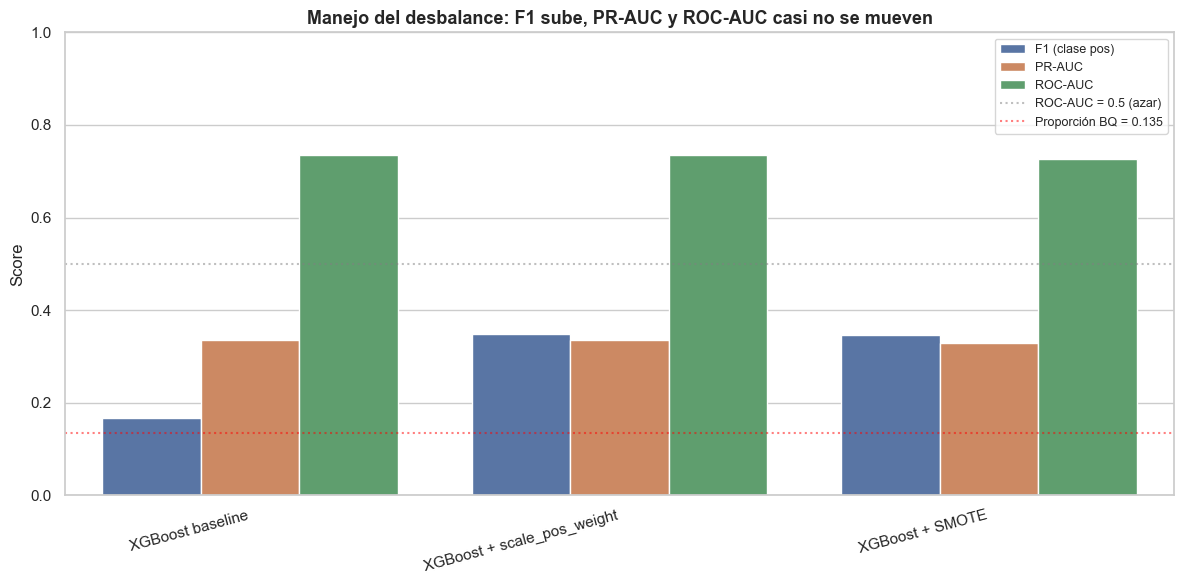

In [8]:
plot_df = all_results[['model', 'f1_pos_mean', 'pr_auc_mean', 'roc_auc_mean']].copy()
plot_df = plot_df.melt(id_vars='model', var_name='metric', value_name='score')
plot_df['metric'] = plot_df['metric'].map({
    'f1_pos_mean': 'F1 (clase pos)',
    'pr_auc_mean': 'PR-AUC',
    'roc_auc_mean': 'ROC-AUC',
})

model_order = all_results['model'].tolist()

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=plot_df, x='model', y='score', hue='metric',
            order=model_order, palette='deep', ax=ax, edgecolor='white')

ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='ROC-AUC = 0.5 (azar)')
ax.axhline(y.mean(), color='red', linestyle=':', alpha=0.5, label=f'Proporción BQ = {y.mean():.3f}')

ax.set_title('Manejo del desbalance: F1 sube, PR-AUC y ROC-AUC casi no se mueven',
             fontweight='bold', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='upper right', fontsize=9)
plt.xticks(rotation=15, ha='right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '10_imbalance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Guardar resultados consolidados

In [9]:
all_results.to_csv(PROCESSED_DATA_DIR / 'imbalance_results.csv', index=False)
print(f'Resultados guardados en: {PROCESSED_DATA_DIR / "imbalance_results.csv"}')

Resultados guardados en: ../data/processed/imbalance_results.csv


---
## 9. Conclusiones del Notebook 06

### Hallazgo central — El desbalance afecta al threshold, no al ranking

| Métrica | Baseline | Weighted | SMOTE | Lectura |
|---|---|---|---|---|
| F1 (pos) | 0.167 | 0.349 | 0.346 | F1 más que se duplica con manejo de desbalance |
| Precision | 0.556 | 0.235 | 0.236 | Trade-off: menos precision a cambio de mucho más recall |
| Recall | 0.098 | 0.677 | 0.645 | El recall pasa de detectar 1 de 10 BQs a detectar 7 de 10 |
| PR-AUC | 0.336 | 0.336 | 0.330 | Casi idéntico — el ranking interno del modelo es el mismo |
| ROC-AUC | 0.736 | 0.735 | 0.727 | Casi idéntico — confirma lo anterior |

**Diagnóstico:** las tres configuraciones tienen prácticamente la misma capacidad de discriminación (PR-AUC ≈ 0.33 en todas). Lo que cambia es **dónde se sitúan las probabilidades respecto al threshold 0.5**:

- **Baseline:** probabilidades comprimidas hacia 0.13 (la prevalencia base). Casi nadie cruza el umbral 0.5, por eso recall = 10%.
- **Weighted / SMOTE:** probabilidades desplazadas hacia arriba. Muchos cruzan 0.5, por eso recall = 65-68%.

### ¿Por qué Weighted gana a SMOTE?

Empate técnico en F1, pero `scale_pos_weight` es preferible por:

1. **Más rápido:** 1.84s vs 5.86s por fit (3x).
2. **PR-AUC y ROC-AUC ligeramente superiores:** SMOTE introduce ruido por interpolar features categóricas one-hot (Country, Gender), generando perfiles imposibles tipo "0.4 España + 0.6 Kenia" o "género 0.5".
3. **Sin riesgo de leakage** si se implementa mal (con `scale_pos_weight` no hay datos sintéticos de los que preocuparse).
4. **Menos hiperparámetros que tocar:** SMOTE tiene `k_neighbors`, `sampling_strategy`, etc.; `scale_pos_weight` es un solo número con fórmula cerrada.

### Implicación para el siguiente notebook

Como las tres configuraciones tienen capacidad de ranking similar, **el siguiente cuello de botella ya no es el desbalance**. Es el **threshold de decisión**. En el N07 vamos a:

1. Tomar el modelo `XGBoost + scale_pos_weight` como modelo final.
2. Optimizar el threshold sobre la curva Precision-Recall en CV.
3. Reportar varios thresholds: F1-óptimo, F2-óptimo (más recall), F0.5-óptimo (más precision).
4. Análisis de slices por género, edad, país.

### Lección de ML para la presentación

> Cuando un modelo desbalanceado tiene PR-AUC alto pero F1 bajo, el problema casi nunca es de capacidad. Es de calibración. Antes de cambiar de modelo, prueba (1) ajustar el peso de la clase minoritaria en la pérdida, y (2) optimizar el threshold de decisión. Cambiar de modelo o de algoritmo es la última opción, no la primera.

### Decisión aplazada

GridSearch sobre los hiperparámetros de XGBoost (`n_estimators`, `max_depth`, `learning_rate`) lo dejamos para después del N07. Razón: si el cuello de botella es el threshold, optimizar hiperparámetros sin tunear threshold es perder el tiempo.